# Stage C — Exploratory Data Analysis

## Objective

The purpose of this analysis is to understand the agricultural dataset
before developing the machine-learning model.

The analysis will examine:

- the structure and size of the datasets
- missing values and data quality
- distributions of important variables
- relationships between agricultural factors and yield
- differences between crops, farms, and plots
- potential predictors of harvest yield
- observations that may affect feature engineering and model selection

The analysis uses the cleaned data stored in PostgreSQL after the Stage B
data-loading pipeline.

In [1]:
import pandas as pd
import numpy as np
import psycopg2
from pathlib import Path
import matplotlib.pyplot as plt
import sys


In [2]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.append(str(PROJECT_ROOT / "src"))

from db import DB_CONFIG

print("Password loaded:", DB_CONFIG["password"] is not None)

conn = psycopg2.connect(**DB_CONFIG)

print("Database connection successful.")

Password loaded: True
Database connection successful.


In [6]:
farms = pd.read_sql(
    "SELECT * FROM farms",
    conn
)

plots = pd.read_sql(
    "SELECT * FROM plots",
    conn
)

harvests = pd.read_sql(
    "SELECT * FROM harvests",
    conn
)

C:\Users\keziah\AppData\Local\Temp\ipykernel_46948\3563298958.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  farms = pd.read_sql(
C:\Users\keziah\AppData\Local\Temp\ipykernel_46948\3563298958.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  plots = pd.read_sql(
C:\Users\keziah\AppData\Local\Temp\ipykernel_46948\3563298958.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  harvests = pd.read_sql(


In [7]:
print(f"Farms {farms.shape}")
print(f"Plots {plots.shape}")
print(f"Harvests {harvests.shape}")

Farms (420, 7)
Plots (1817, 6)
Harvests (11385, 13)


In [8]:
farms.head()

,farm_id,village,division,soil_type,altitude_m,household_size,extension_visits_yr
0,FM-0001,Santa,Mezam,clay loam,1423,10.0,NaN
1,FM-0002,Nkambe,Donga-Mantung,ferralitic,1123,6.0,1.0
2,FM-0003,Belo,Boyo,clay loam,1391,4.0,0.0
3,FM-0004,Nkambe,Donga-Mantung,hydromorphic,1918,7.0,4.0
4,FM-0005,Belo,Boyo,hydromorphic,1484,5.0,3.0


In [11]:
farms.info()

<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   farm_id              420 non-null    str    
 1   village              420 non-null    str    
 2   division             420 non-null    str    
 3   soil_type            420 non-null    str    
 4   altitude_m           420 non-null    int64  
 5   household_size       378 non-null    float64
 6   extension_visits_yr  374 non-null    float64
dtypes: float64(2), int64(1), str(4)
memory usage: 23.1 KB


In [13]:
farms.describe()

,altitude_m,household_size,extension_visits_yr
count,420.000000,378.000000,374.000000
mean,1434.023810,6.642857,1.457219
std,449.657021,2.389625,1.354978
min,605.000000,3.000000,0.000000
25%,1060.500000,4.000000,0.000000
50%,1447.000000,7.000000,1.000000
75%,1806.000000,9.000000,2.000000
max,2200.000000,10.000000,4.000000


In [14]:
plots.head()

,plot_id,farm_id,area_ha,crop,slope_pct,irrigated
0,PL-00001,FM-0001,0.421,soya,4.2,True
1,PL-00002,FM-0001,1.624,huckleberry,NaN,True
2,PL-00003,FM-0001,1.530,soya,16.8,False
3,PL-00004,FM-0001,0.712,irish potato,NaN,True
4,PL-00005,FM-0001,0.513,soya,NaN,False


In [15]:
plots.info()

<class 'pandas.DataFrame'>
RangeIndex: 1817 entries, 0 to 1816
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   plot_id    1817 non-null   str    
 1   farm_id    1817 non-null   str    
 2   area_ha    1817 non-null   float64
 3   crop       1817 non-null   str    
 4   slope_pct  1188 non-null   float64
 5   irrigated  1817 non-null   bool   
dtypes: bool(1), float64(2), str(3)
memory usage: 72.9 KB


In [16]:
plots.describe()

,area_ha,slope_pct
count,1817.000000,1188.000000
mean,0.820448,14.309764
std,0.444532,7.897814
min,0.080000,1.000000
25%,0.474000,7.275000
50%,0.776000,14.200000
75%,1.144000,21.200000
max,2.724000,28.000000


In [17]:
harvests.head()

,harvest_id,plot_id,season,planting_date,harvest_date,rainfall_mm,fertiliser_kg_ha,seed_variety,labour_days,yield_kg_ha,buyer_grade,post_harvest_loss_pct,met_target
0,HV-004158,PL-00661,2024A,2024-03-26,2024-07-21,627.2,85.4,TGX-1448,12,1020.5,A,2.5,True
1,HV-006229,PL-00990,2022A,2022-03-13,2022-08-07,662.4,88.9,local,12,5203.5,A,5.8,True
2,HV-008585,PL-01373,2023A,2023-03-17,2023-07-17,562.0,126.6,TGX-1448,24,1953.4,A,8.6,True
3,HV-005944,PL-00942,2026A,2026-03-16,2026-08-23,529.8,34.9,TGX-1448,46,1539.6,A,4.7,True
4,HV-005055,PL-00802,2022B,2022-08-24,2023-01-13,448.2,NaN,local,58,546.3,C,14.9,False


In [18]:
harvests.info()

<class 'pandas.DataFrame'>
RangeIndex: 11385 entries, 0 to 11384
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   harvest_id             11385 non-null  str    
 1   plot_id                11385 non-null  str    
 2   season                 11385 non-null  str    
 3   planting_date          11385 non-null  object 
 4   harvest_date           11385 non-null  object 
 5   rainfall_mm            11385 non-null  float64
 6   fertiliser_kg_ha       10800 non-null  float64
 7   seed_variety           11385 non-null  str    
 8   labour_days            11385 non-null  int64  
 9   yield_kg_ha            11385 non-null  float64
 10  buyer_grade            11385 non-null  str    
 11  post_harvest_loss_pct  11385 non-null  float64
 12  met_target             11385 non-null  bool   
dtypes: bool(1), float64(4), int64(1), object(2), str(5)
memory usage: 1.1+ MB


In [19]:
harvests.describe()

,rainfall_mm,fertiliser_kg_ha,labour_days,yield_kg_ha,post_harvest_loss_pct
count,11385.000000,10800.000000,11385.000000,11385.000000,11385.000000
mean,654.464778,49.028722,32.134563,1600.053404,10.560817
std,223.897494,31.682499,16.450248,914.441238,7.386406
min,120.000000,0.000000,4.000000,80.000000,2.000000
25%,499.000000,24.700000,18.000000,913.100000,4.900000
50%,651.400000,48.200000,32.000000,1580.300000,7.700000
75%,810.000000,70.800000,46.000000,2240.600000,15.800000
max,1417.000000,162.100000,60.000000,5203.500000,28.000000


In [24]:
print("Columns with missing values for farm")
farms.isna().sum()

Columns with missing values for farm


farm_id                 0
village                 0
division                0
soil_type               0
altitude_m              0
household_size         42
extension_visits_yr    46
dtype: int64

In [25]:
print("Columns with missing values for plots")
plots.isna().sum()

Columns with missing values for plots


plot_id        0
farm_id        0
area_ha        0
crop           0
slope_pct    629
irrigated      0
dtype: int64

In [26]:
print("Columns with missing values for harvest")
harvests.isna().sum()

Columns with missing values for harvest


harvest_id                 0
plot_id                    0
season                     0
planting_date              0
harvest_date               0
rainfall_mm                0
fertiliser_kg_ha         585
seed_variety               0
labour_days                0
yield_kg_ha                0
buyer_grade                0
post_harvest_loss_pct      0
met_target                 0
dtype: int64

In [37]:
def missing_summary(df):
    result = pd.DataFrame({
        "missing_count" : df.isna().sum(),
        "missing_pct" : df.isna().mean() * 100
    })
    return result.sort_values("missing_count", ascending=False)

In [38]:
missing_summary(farms)

,missing_count,missing_pct
extension_visits_yr,46,10.952381
household_size,42,10.000000
farm_id,0,0.000000
division,0,0.000000
village,0,0.000000
altitude_m,0,0.000000
soil_type,0,0.000000


In [39]:
missing_summary(plots)

,missing_count,missing_pct
slope_pct,629,34.617501
plot_id,0,0.000000
farm_id,0,0.000000
area_ha,0,0.000000
crop,0,0.000000
irrigated,0,0.000000


In [40]:
missing_summary(harvests)

,missing_count,missing_pct
fertiliser_kg_ha,585,5.13834
plot_id,0,0.00000
season,0,0.00000
planting_date,0,0.00000
harvest_id,0,0.00000
harvest_date,0,0.00000
rainfall_mm,0,0.00000
seed_variety,0,0.00000
labour_days,0,0.00000
yield_kg_ha,0,0.00000


In [41]:
print(f"Duplicat farms_ids {farms["farm_id"].duplicated().sum()}")
print(f"Duplicat plot_ids {plots["plot_id"].duplicated().sum()}")
print(f"Duplicat harvest_ids {harvests["harvest_id"].duplicated().sum()}")

Duplicat farms_ids 0
Duplicat plot_ids 0
Duplicat harvest_ids 0


## 3. Yield Distribution

Yield is the main outcome of interest for the agricultural analysis.
Understanding its distribution helps identify its typical range,
variation, skewness, and potential outliers.

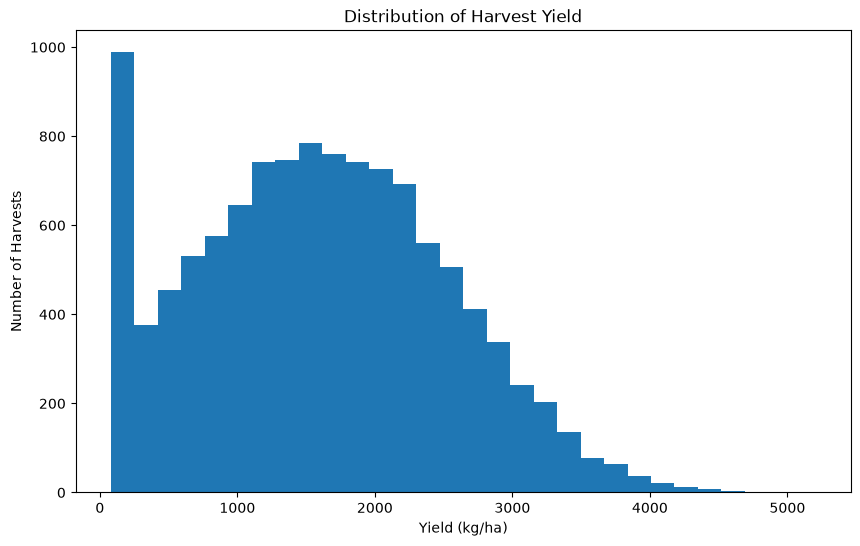

In [62]:
plt.figure(figsize=(10, 6))

plt.hist(
    harvests["yield_kg_ha"].dropna(),
    bins=30
)

plt.xlabel("Yield (kg/ha)")
plt.ylabel("Number of Harvests")
plt.title("Distribution of Harvest Yield")

plt.show()

<Figure size 1200x600 with 0 Axes>

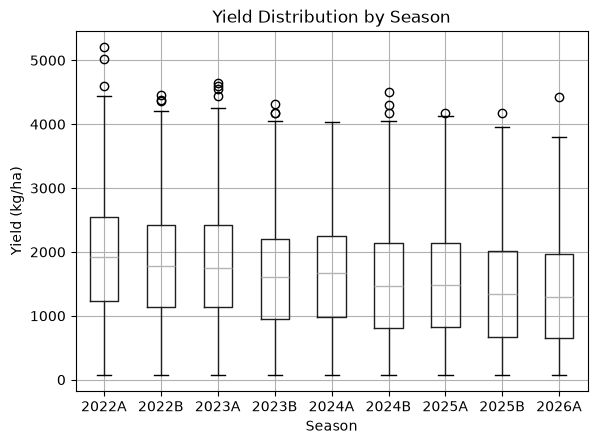

In [57]:
plt.figure(figsize=(12, 6))

harvests.boxplot(
    column="yield_kg_ha",
    by="season"
)

plt.title("Yield Distribution by Season")
plt.suptitle("")

plt.xlabel("Season")
plt.ylabel("Yield (kg/ha)")

plt.show()

In [58]:
harvests["season"].value_counts()

season
2023A    1282
2024B    1274
2026A    1271
2025A    1267
2023B    1265
2025B    1262
2024A    1256
2022A    1256
2022B    1252
Name: count, dtype: int64

In [59]:
plots["crop"].value_counts()

crop
cassava         265
groundnut       254
soya            243
maize           221
beans           219
huckleberry     214
plantain        202
irish potato    199
Name: count, dtype: int64

In [60]:
print("Target counts:")
display(harvests["met_target"].value_counts())

print("\nTarget percentages:")
display(
    (harvests["met_target"].value_counts(normalize=True) * 100)
    .round(2)
)

print("\nTarget data type:")
print(harvests["met_target"].dtype)

Target counts:


met_target
True     6991
False    4394
Name: count, dtype: int64


Target percentages:


met_target
True     61.41
False    38.59
Name: proportion, dtype: float64


Target data type:
bool


## Target Variable: `met_target`

The target variable for the machine-learning task is `met_target`, which is
a Boolean variable indicating whether the harvest met the defined target.

The dataset contains 11,385 valid harvest records:

- 6,991 records (`61.41%`) have `met_target = True`.
- 4,394 records (`38.59%`) have `met_target = False`.

The target contains no missing values and is stored as a Boolean data type.

The two classes are not perfectly balanced, but neither class is extremely
rare. Therefore, class distribution should still be considered when
evaluating the eventual classification model.

A baseline classifier that always predicts the majority class (`True`)
would achieve approximately 61.41% accuracy. The machine-learning model
should therefore be evaluated against this baseline rather than accuracy
being interpreted in isolation.

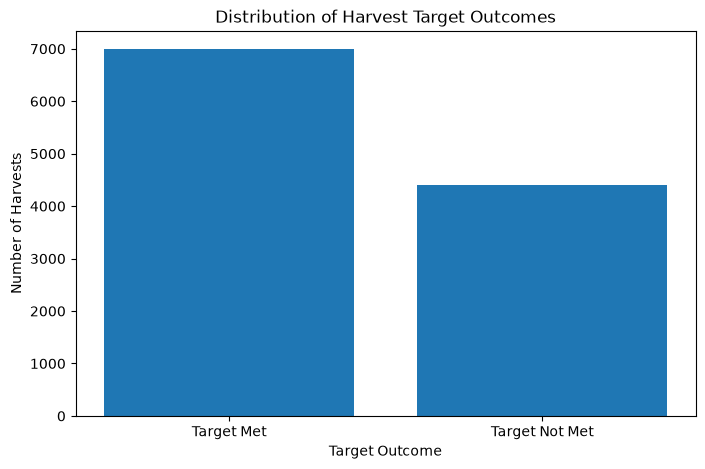

In [63]:
target_counts = harvests["met_target"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    ["Target Met", "Target Not Met"],
    [
        target_counts.get(True, 0),
        target_counts.get(False, 0)
    ]
)

plt.xlabel("Target Outcome")
plt.ylabel("Number of Harvests")
plt.title("Distribution of Harvest Target Outcomes")

plt.show()

In [64]:
harvests.dtypes

harvest_id                   str
plot_id                      str
season                       str
planting_date             object
harvest_date              object
rainfall_mm              float64
fertiliser_kg_ha         float64
seed_variety                 str
labour_days                int64
yield_kg_ha              float64
buyer_grade                  str
post_harvest_loss_pct    float64
met_target                  bool
dtype: object

In [65]:
plots.dtypes

plot_id          str
farm_id          str
area_ha      float64
crop             str
slope_pct    float64
irrigated       bool
dtype: object

In [66]:
farms.dtypes

farm_id                    str
village                    str
division                   str
soil_type                  str
altitude_m               int64
household_size         float64
extension_visits_yr    float64
dtype: object

In [67]:
print("Crops:")
display(plots["crop"].value_counts())

print("Seasons:")
display(harvests["season"].value_counts())

print("Seed varieties:")
display(harvests["seed_variety"].value_counts())

print("Buyer grades:")
display(harvests["buyer_grade"].value_counts())

print("Irrigation:")
display(plots["irrigated"].value_counts())

Crops:


crop
cassava         265
groundnut       254
soya            243
maize           221
beans           219
huckleberry     214
plantain        202
irish potato    199
Name: count, dtype: int64

Seasons:


season
2023A    1282
2024B    1274
2026A    1271
2025A    1267
2023B    1265
2025B    1262
2024A    1256
2022A    1256
2022B    1252
Name: count, dtype: int64

Seed varieties:


seed_variety
local            4478
Vanda             798
TGX-1448          730
improved          646
CRBP-39           641
TMS-96            557
Excel             557
MAC-44            508
PNN               439
CMS-8704          381
ATP-Y             347
Kassaï            346
Tubira            339
Cipira            312
Bambui-Wonder     306
Name: count, dtype: int64

Buyer grades:


buyer_grade
A    6991
C    2966
B    1428
Name: count, dtype: int64

Irrigation:


irrigated
False    1054
True      763
Name: count, dtype: int64

In [68]:
display(farms.columns.tolist())
display(plots.columns.tolist())
display(harvests.columns.tolist())

['farm_id',
 'village',
 'division',
 'soil_type',
 'altitude_m',
 'household_size',
 'extension_visits_yr']

['plot_id', 'farm_id', 'area_ha', 'crop', 'slope_pct', 'irrigated']

['harvest_id',
 'plot_id',
 'season',
 'planting_date',
 'harvest_date',
 'rainfall_mm',
 'fertiliser_kg_ha',
 'seed_variety',
 'labour_days',
 'yield_kg_ha',
 'buyer_grade',
 'post_harvest_loss_pct',
 'met_target']